# File src/eigen.py

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import eigh

In [ ]:
def build_2d_hamiltonian(N=20, potential='well'):
    """
    Build a discretized 2D Hamiltonian on an N x N grid.
    Parameters
    ----------
    N : int
    Number of points in each dimension (N^2 total points).
    potential : str
    Choose the potential. 'well' or 'harmonic' or 'cylindrical_shell' examples.
    Returns
    -------
    H : ndarray of shape (N^2, N^2)
    The Hamiltonian matrix approximating -d^2/dx^2 - d^2/dy^2 + V(x,y).
    """
    dx = 1. / float(N) # grid spacing, can be arbitrary
    inv_dx2 = float(N * N) # 1/dx^2
    H = np.zeros((N*N, N*N), dtype=np.float64)
    
    # Helper function to map (i,j) -> linear index
    def idx(i, j):
        return i * N + j
        
    # Potential function
    def V(i, j):
                
        # Example 1: infinite square well -> zero in interior, large outside
        if potential == 'well':
            # No boundary enforcement here, but can skip boundary wavefunction
            return 0.
        
        # Example 2: 2D harmonic oscillator around center
        elif potential == 'harmonic':
            x = (i - N/2) * dx
            y = (j - N/2) * dx
            # Quadratic potential V = k * (x^2 + y^2)
            return 4. * (x**2 + y**2)
        
        elif potential == 'shell_oscillator':
            # Oscillator with shell: V=4V higher between R1 and R2 apart from the harmonic potential
            x = (i - N/2) * dx
            y = (j - N/2) * dx
            
            # Cylindrical shell: V=4V higher between R1 and R2 apart from the harmonic potential
            r = np.sqrt(x**2 + y**2)
            R1 = 0.5  # radius of inner boundary
            R2 = 0.75 # radius of outer boundary
            V = 4. * (x**2 + y**2)
            if (r < R1) or (r > R2):
                return V
            else:
                V += 4. # add barrier height in the shell region
                return V # large potential between the boundaries
        
        else:
            return 0.
    
    
        
    # Build the matrix: For each (i, j), set diagonal for 2D Laplacian plus V
    for i in range(N):
        for j in range(N):
            row = idx(i,j)
            # Potential
            H[row, row] = 4. * inv_dx2 + V(i,j) # "Kinetic" ~ -4/dx^2 in 2D FD
            
            # Neighbors (assuming no boundary conditions or Dirichlet)
            if i > 0: # up
                H[row, idx(i-1, j)] = inv_dx2
            if i < N-1: # down
                H[row, idx(i+1, j)] = inv_dx2
            if j > 0: # left
                H[row, idx(i, j-1)] = inv_dx2
            if j < N-1: # right
                H[row, idx(i, j+1)] = inv_dx2
    
    return H


In [50]:
    
def plot_potential(n, potential): 

    x = np.linspace(-1, 1, n)
    y = np.linspace(-1, 1, n)
    X, Y = np.meshgrid(x, y)
    V = np.zeros_like(X)
    
    if potential == 'harmonic':
        V = 4. * (X**2 + Y**2)
    elif potential == 'shell_oscillator':
        R1 = 0.5  # radius of inner boundary
        R2 = 0.75 # radius of outer boundary
        r = np.sqrt(X**2 + Y**2)
        V = 4. * (X**2 + Y**2)
        V[(r >= R1) & (r <= R2)] += 4        

    plt.figure()
    plt.imshow(V.T, origin='lower', extent=(-1, 1, -1, 1))
    plt.colorbar()
    plt.title(f'{potential} Potential V(x,y)')
    plt.show()
    plt.savefig(f'{potential}_potential.pdf', dpi=300)


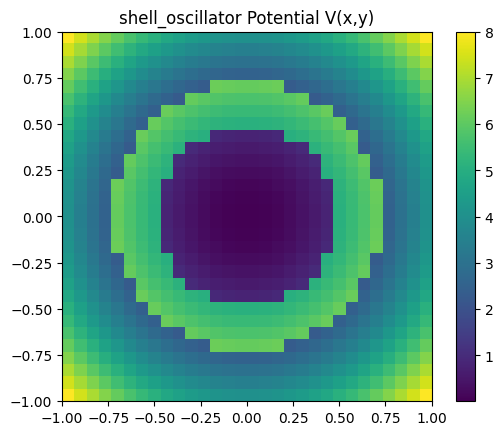

Lowest 10 eigenvalues: [ 18.7942911   46.65184793  46.66122614  74.68136478  92.31339216
  92.63368175 120.60981949 120.61929077 155.86880829 155.87777447]


<Figure size 640x480 with 0 Axes>

In [ ]:

def solve_eigen(N=20, potential='well', n_eigs=None):
    """
    Build a 2D Hamiltonian and solve for the lowest n_eigs eigenvalues.
    Parameters
    ----------
    N : int
    Grid points in each dimension.
    potential : str
    Potential type.
    n_eigs : int
    Number of eigenvalues to return.
    Returns
    -------
    vals : array_like
    The lowest n_eigs eigenvalues sorted ascending.
    vecs : array_like
    The corresponding eigenvectors.
    """
    H = build_2d_hamiltonian(N, potential)

    # Solve entire spectrum (careful for large N)
    vals, vecs = eigh(H)

    # Sort
    idx_sorted = np.argsort(vals)
    vals_sorted = vals[idx_sorted]
    vecs_sorted = vecs[:, idx_sorted]
    grnd_vec = vecs_sorted[:, 0] # ground state wavefunction (lowest eigenvalue)

    if n_eigs is None:
        return vals_sorted, vecs_sorted, grnd_vec
    else:
        return vals_sorted[:n_eigs], vecs_sorted[:, :n_eigs], grnd_vec

if __name__ == '__main__':
    
    N = 30
    potential = 'shell_oscillator'
    n_eigs = 10
        
    vals, vecs, grnd_vec = solve_eigen(N=N, potential=potential, n_eigs=n_eigs)
    
    plot_potential(N, potential=potential)
    
    print(f"Lowest {n_eigs} eigenvalues:", vals)
    np.savetxt(f'eigs_N{N}.txt', vals)
    

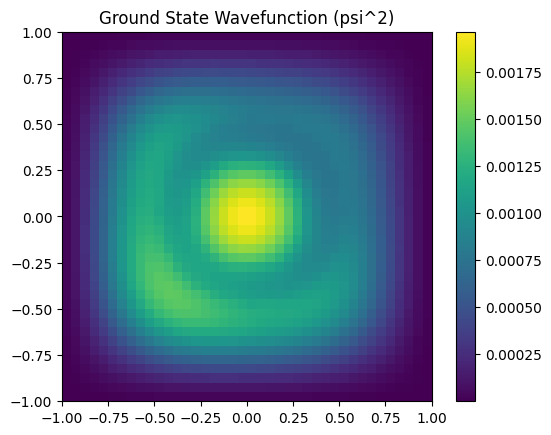

<Figure size 640x480 with 0 Axes>

In [91]:
N = 40
Z = np.loadtxt(f'grnd_psi_2d_N{N}.txt')
plt.imshow(Z.T, origin='lower', extent=(-1, 1, -1, 1))
plt.colorbar()
plt.title('Ground State Wavefunction (psi^2)')
plt.show()
plt.savefig(f'grnd_psi_2d_N{N}.pdf', dpi= 300)

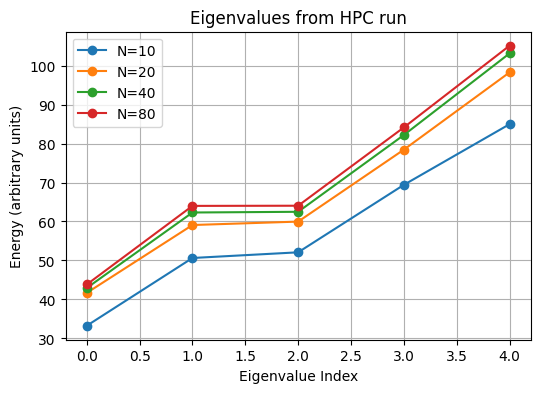

<Figure size 640x480 with 0 Axes>

In [92]:
# Load HPC results
N = [10, 20, 40, 80] # Adjust as needed (use the largest N you ran on HPC)
potential = 'shell_oscillator' # 'harmonic'

E = []

plt.figure(figsize=(6,4))
for n in N:
    data = np.loadtxt(f'{potential}/eigs_N{n}_{potential}.txt')    
    E.append(data)    
    plt.plot(data, 'o-', label=f'N={n}')

plt.legend()
plt.xlabel('Eigenvalue Index')
plt.ylabel('Energy (arbitrary units)')
plt.title(f'Eigenvalues from HPC run')
plt.grid()
plt.show()
plt.savefig(f'{potential}_eigenvalues.pdf', dpi=300)

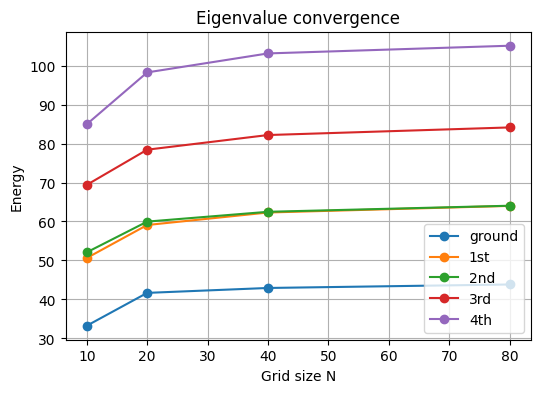

<Figure size 640x480 with 0 Axes>

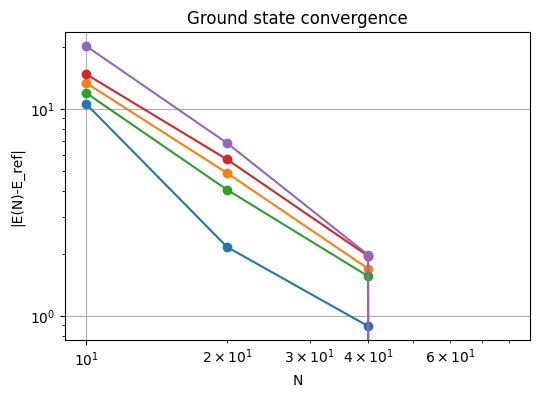

<Figure size 640x480 with 0 Axes>

In [93]:
E0 = [i[0] for i in E]
E1 = [i[1] for i in E]
E2 = [i[2] for i in E]
E3 = [i[3] for i in E]
E4 = [i[4] for i in E]

plt.figure(figsize=(6,4))
plt.plot(N, E0, 'o-', label='ground')
plt.plot(N, E1, 'o-', label='1st')
plt.plot(N, E2, 'o-', label='2nd')
plt.plot(N, E3, 'o-', label='3rd')
plt.plot(N, E4, 'o-', label='4th')

plt.xlabel('Grid size N')
plt.ylabel('Energy')
plt.title('Eigenvalue convergence')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig(f'{potential}_convergence.pdf', dpi=300)


plt.figure(figsize=(6,4))
plt.loglog(N, np.abs(np.array(E0)-E0[-1]), 'o-')
plt.loglog(N, np.abs(np.array(E1)-E1[-1]), 'o-')
plt.loglog(N, np.abs(np.array(E2)-E2[-1]), 'o-')
plt.loglog(N, np.abs(np.array(E3)-E3[-1]), 'o-')
plt.loglog(N, np.abs(np.array(E4)-E4[-1]), 'o-')
plt.xlabel('N')
plt.ylabel('|E(N)-E_ref|')
plt.title('Ground state convergence')
plt.grid()
plt.show()
plt.savefig(f'{potential}_convergence_loglog.pdf', dpi=300)